## NIH Chest X-rays multimodal clustering pipeline

This notebook keeps the same overall flow as the CheXpert version:

1. load and clean tabular metadata
2. parse multi-label findings from `Finding Labels`
3. resolve image paths from the NIH folder structure
4. extract image features with ViT
5. merge tabular + image features
6. standardize, reduce with PCA, cluster, evaluate, and visualize with t-SNE


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, ViTModel

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except ImportError:
    hdbscan = None
    HDBSCAN_AVAILABLE = False


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


## Pipeline for data processing

This class keeps the same role as in the CheXpert notebook, but it adapts the dataset-specific pieces for NIH:

1. read metadata from `Data_Entry_2017.csv`
2. split `Finding Labels` on `|` and create multi-hot columns
3. match each `Image Index` to its file inside the nested image folders
4. extract ViT features from the resolved image paths
5. combine age, sex, diagnosis labels, and image embeddings into one clustering matrix


In [2]:
class NIHChestXrayMultimodalPreprocessor:
    """
    End-to-end preprocessing pipeline for NIH Chest X-rays multimodal clustering.

    Differences from CheXpert:
    - labels are stored as pipe-separated strings in `Finding Labels`
    - images are distributed across nested folders, so paths are resolved by filename
    """

    def __init__(
        self,
        base_path="/kaggle/input/datasets/organizations/nih-chest-xrays/data",
        model_name="google/vit-base-patch16-224-in21k",
        batch_size=16,
        drop_no_finding=True,
        device=None,
    ):
        self.base_path = base_path
        self.model_name = model_name
        self.batch_size = batch_size
        self.drop_no_finding = drop_no_finding
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.processor = AutoImageProcessor.from_pretrained(self.model_name)
        self.model = ViTModel.from_pretrained(self.model_name).to(self.device)
        self.model.eval()

        self.label_cols = None
        self.image_index_map = None

    def build_image_index(self):
        image_candidates = glob.glob(os.path.join(self.base_path, "**", "*.png"), recursive=True)
        if not image_candidates:
            raise ValueError(f"No PNG images found under {self.base_path}")

        self.image_index_map = {
            os.path.basename(path): path for path in image_candidates
        }
        return self.image_index_map

    def _split_labels(self, label_string):
        if pd.isna(label_string):
            return []
        return [label.strip() for label in str(label_string).split("|") if label.strip()]

    def prepare_dataframe(self, csv_path, split_list_path=None):
        df = pd.read_csv(csv_path)

        if split_list_path is not None:
            with open(split_list_path, "r", encoding="utf-8") as fh:
                split_names = {line.strip() for line in fh if line.strip()}
            df = df[df["Image Index"].isin(split_names)].copy()

        if self.image_index_map is None:
            self.build_image_index()

        df["Path"] = df["Image Index"].map(self.image_index_map)
        df = df[df["Path"].notna()].copy()

        label_lists = df["Finding Labels"].apply(self._split_labels)
        label_classes = sorted({label for labels in label_lists for label in labels})
        self.label_cols = [label for label in label_classes if label != "No Finding"]

        for label in self.label_cols:
            df[label] = label_lists.apply(lambda labels: int(label in labels))

        df["No Finding"] = label_lists.apply(lambda labels: int("No Finding" in labels))
        df["label_count"] = df[self.label_cols].sum(axis=1)

        return df.reset_index(drop=True)

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        if self.drop_no_finding and "No Finding" in df.columns:
            df = df[df["No Finding"] != 1].copy()

        if "Patient Gender" in df.columns:
            df["Patient Gender"] = df["Patient Gender"].astype(str).str.strip()
            df = df[~df["Patient Gender"].str.lower().isin(["unknown", "nan", "none", ""])].copy()

        if "Patient Age" in df.columns:
            df["Patient Age"] = pd.to_numeric(df["Patient Age"], errors="coerce")
            df = df[df["Patient Age"].notna()].copy()

            q1 = df["Patient Age"].quantile(0.25)
            q3 = df["Patient Age"].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df = df[(df["Patient Age"] >= lower) & (df["Patient Age"] <= upper)].copy()

        return df.reset_index(drop=True)

    def extract_image_features(self, df: pd.DataFrame) -> pd.DataFrame:
        if "Path" not in df.columns:
            raise ValueError("Path column is required for image feature extraction.")

        image_paths = df["Path"].tolist()
        all_features = []
        kept_paths = []

        for start in tqdm(range(0, len(image_paths), self.batch_size), desc="Extracting image features"):
            batch_paths = image_paths[start:start + self.batch_size]
            images = []
            batch_kept_paths = []

            for img_path in batch_paths:
                try:
                    img = Image.open(img_path).convert("RGB")
                    images.append(img)
                    batch_kept_paths.append(img_path)
                except Exception as exc:
                    print(f"Skipping {img_path}: {exc}")

            if not images:
                continue

            inputs = self.processor(images=images, return_tensors="pt")
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = self.model(**inputs)
                feats = outputs.pooler_output if outputs.pooler_output is not None else outputs.last_hidden_state[:, 0, :]

            all_features.append(feats.cpu().numpy())
            kept_paths.extend(batch_kept_paths)

        if not all_features:
            raise ValueError("No image features extracted. Check image paths and dataset mount.")

        all_features = np.vstack(all_features)
        feature_cols = [f"img_feat_{i}" for i in range(all_features.shape[1])]
        image_df = pd.DataFrame(all_features, columns=feature_cols)
        image_df.insert(0, "Path", kept_paths)
        return image_df

    def preprocess_tabular(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        keep_cols = ["Path"]

        if "Patient Age" in df.columns:
            keep_cols.append("Patient Age")

        if "Patient Gender" in df.columns:
            gender_dummies = pd.get_dummies(df["Patient Gender"], prefix="Patient Gender")
            df = pd.concat([df, gender_dummies], axis=1)
            keep_cols.extend(gender_dummies.columns.tolist())

        keep_cols.extend([col for col in self.label_cols if col in df.columns])
        df = df[keep_cols].copy()

        return df

    def merge_multimodal(self, tabular_df: pd.DataFrame, image_df: pd.DataFrame) -> pd.DataFrame:
        merged = tabular_df.merge(image_df, on="Path", how="inner")
        merged = merged.drop(columns=["Path"], errors="ignore")
        return merged

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        clean_df = self.clean_data(df)
        image_features = self.extract_image_features(clean_df)
        tabular_features = self.preprocess_tabular(clean_df)
        multimodal_df = self.merge_multimodal(tabular_features, image_features)
        return multimodal_df

    def prepare_for_clustering(self, multimodal_df: pd.DataFrame, use_pca=True, n_pca_components=50, fit=True):
        X = multimodal_df.copy()
        X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

        if fit:
            steps = [("scaler", StandardScaler())]
            if use_pca:
                steps.append(("pca", PCA(n_components=n_pca_components, random_state=42)))
            self.clustering_preprocessor = Pipeline(steps)
            return self.clustering_preprocessor.fit_transform(X)

        if not hasattr(self, "clustering_preprocessor"):
            raise ValueError("Call prepare_for_clustering(..., fit=True) first.")
        return self.clustering_preprocessor.transform(X)


## Load and inspect NIH metadata

This section replaces the CheXpert `train.csv` loading logic.

It loads the NIH metadata file, applies the provided split lists, builds binary disease columns from `Finding Labels`, and samples the training set for faster experimentation.


In [3]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")
TRAIN_VAL_LIST_PATH = os.path.join(BASE_PATH, "train_val_list.txt")
TEST_LIST_PATH = os.path.join(BASE_PATH, "test_list.txt")

pipeline = NIHChestXrayMultimodalPreprocessor(
    base_path=BASE_PATH,
    model_name="google/vit-base-patch16-224-in21k",
    batch_size=4,
    drop_no_finding=True,
)

train_df = pipeline.prepare_dataframe(CSV_PATH, TRAIN_VAL_LIST_PATH)
test_df = pipeline.prepare_dataframe(CSV_PATH, TEST_LIST_PATH)

sample_size = min(20000, len(train_df))
train_df = train_df.sample(n=sample_size, random_state=42).reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Disease labels:", pipeline.label_cols)
train_df[["Image Index", "Finding Labels", "label_count"] + pipeline.label_cols[:5]].head()


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Train rows: 20000
Test rows: 25596
Disease labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


,Image Index,Finding Labels,label_count,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion
0,00028324_001.png,Mass|Pleural_Thickening,2,0,0,0,0,0
1,00006949_004.png,No Finding,0,0,0,0,0,0
2,00003923_000.png,Atelectasis,1,1,0,0,0,0
3,00017365_002.png,No Finding,0,0,0,0,0,0
4,00018947_001.png,No Finding,0,0,0,0,0,0


## Label distribution

The NIH dataset is multi-label and imbalanced, so it is useful to inspect how often each finding appears in the sampled training data before clustering.


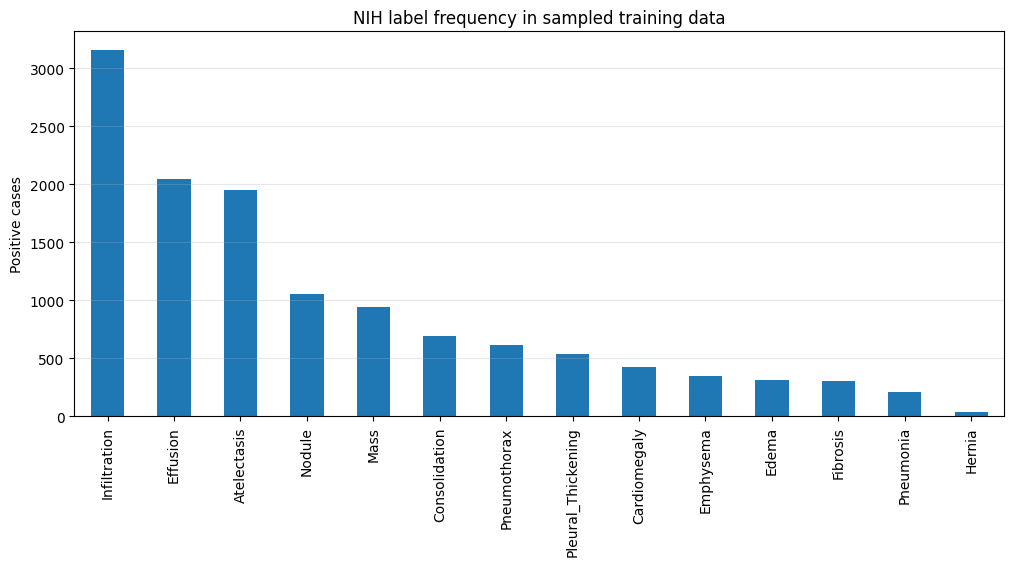

In [4]:
label_distribution = train_df[pipeline.label_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
label_distribution.plot(kind="bar")
plt.title("NIH label frequency in sampled training data")
plt.ylabel("Positive cases")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Build multimodal training matrix

This is the same core preprocessing stage as in the CheXpert pipeline:

- clean the metadata
- extract image embeddings
- keep only age, sex, and diagnosis labels on the tabular side
- merge tabular and image features
- standardize and reduce dimensionality with PCA


In [5]:
train_multimodal = pipeline.fit_transform(train_df)
X_train = pipeline.prepare_for_clustering(
    train_multimodal,
    use_pca=True,
    n_pca_components=50,
    fit=True,
)

print("Train multimodal shape:", train_multimodal.shape)
print("Train clustering shape:", X_train.shape)


Extracting image features:   0%|          | 0/2095 [00:00<?, ?it/s]

Train multimodal shape: (8377, 785)
Train clustering shape: (8377, 50)


# Evaluation:
- silhouette
- davies bouldin
- calinski harabasz

The evaluation logic stays the same. The multimodal feature matrix is standardized first, and PCA remains optional exactly as in the CheXpert notebook.


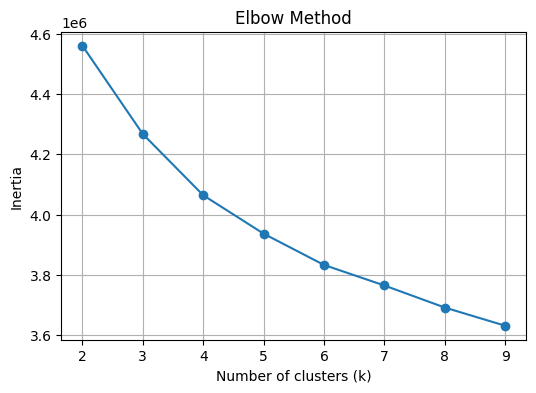

[4560955.468349557,
 4267478.675888034,
 4064064.9857731014,
 3936358.5866796924,
 3832386.2677624575,
 3764078.2011543,
 3690805.659912058,
 3630360.1924673305]

In [6]:
def evaluate_clustering(X, labels, algorithm_name):
    labels = np.asarray(labels)
    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]

    n_clusters = len(set(labels_eval))
    if n_clusters < 2:
        return {
            "algorithm": algorithm_name,
            "n_clusters": n_clusters,
            "noise_points": int(np.sum(labels == -1)),
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }

    return {
        "algorithm": algorithm_name,
        "n_clusters": n_clusters,
        "noise_points": int(np.sum(labels == -1)),
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval),
    }

def elbow_method(X, k_range=range(2, 11)):
    inertia = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        model.fit(X)
        inertia.append(model.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(list(k_range), inertia, marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.grid(True)
    plt.show()
    return inertia

elbow_method(X_train, k_range=range(2, 10))


Apply clustering models
- K-means
- HDBSCAN
- Hierarchical Clustering
- Gaussian Mixture Model
- Spectral Clustering

This section runs the same family of clustering models on the NIH multimodal feature matrix and ranks them with the evaluation metrics above.


### Find best K
- Elbow

Start with the same elbow heuristic used in the CheXpert notebook to get a reasonable range for centroid-based models.


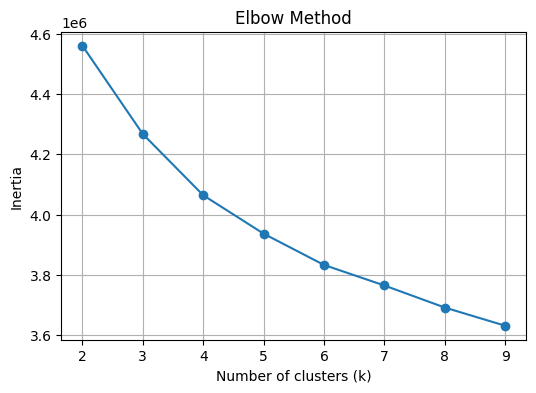

,k,inertia
0,2,4.560955e+06
1,3,4.267479e+06
2,4,4.064065e+06
3,5,3.936359e+06
4,6,3.832386e+06
5,7,3.764078e+06
6,8,3.690806e+06
7,9,3.630360e+06


In [7]:
def elbow_method(X, k_range=range(2, 11)):
    inertia = []

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        model.fit(X)
        inertia.append(model.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(list(k_range), inertia, marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.grid(True)
    plt.show()

    elbow_df = pd.DataFrame({"k": list(k_range), "inertia": inertia})
    return elbow_df

elbow_df = elbow_method(X_train, k_range=range(2, 10))
elbow_df


### Find best K for Hierarchical Clustering

Hierarchical clustering does not use the elbow objective directly, so this section evaluates a range of `k` values and picks the one with the best silhouette score.


In [8]:
def tune_hierarchical_k(X, k_values=range(2, 10)):
    rows = []

    for k in k_values:
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(X)
        row = evaluate_clustering(X, labels, f"HC_k={k}")
        row["k"] = k
        rows.append(row)

    hc_results = pd.DataFrame(rows).sort_values(by="silhouette", ascending=False)
    best_k = int(hc_results.iloc[0]["k"])
    return best_k, hc_results

best_hc_k, hc_tuning_results = tune_hierarchical_k(X_train, k_values=range(2, 10))
print("Best k for Hierarchical Clustering:", best_hc_k)
hc_tuning_results


Best k for Hierarchical Clustering: 2


,algorithm,n_clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz,k
0,HC_k=2,2,0,0.110277,2.794331,1031.115005,2
1,HC_k=3,3,0,0.088628,3.117968,728.187409,3
2,HC_k=4,4,0,0.081134,2.849859,610.555618,4
3,HC_k=5,5,0,0.045252,3.212258,535.290466,5
4,HC_k=6,6,0,0.039087,3.111440,480.358165,6
5,HC_k=7,7,0,0.032676,3.173540,431.169621,7
7,HC_k=9,9,0,0.026578,3.291441,362.376005,9
6,HC_k=8,8,0,0.023685,3.202434,392.094216,8


### Find best params for HDBSCAN

As in the CheXpert notebook, HDBSCAN is tuned over a small grid of `min_cluster_size`, `min_samples`, and `cluster_selection_method`, then ranked with the same clustering metrics.


In [9]:
def tune_hdbscan(X, min_cluster_sizes=None, min_samples_values=None, cluster_selection_methods=None):
    if not HDBSCAN_AVAILABLE:
        print("hdbscan is not installed; skipping HDBSCAN tuning.")
        return None, pd.DataFrame()

    n_samples = len(X)
    if min_cluster_sizes is None:
        min_cluster_sizes = sorted({
            max(10, n_samples // 500),
            max(20, n_samples // 200),
            max(30, n_samples // 100),
            max(50, n_samples // 50),
        })
    if min_samples_values is None:
        min_samples_values = [1, 5, 10]
    if cluster_selection_methods is None:
        cluster_selection_methods = ["eom", "leaf"]

    rows = []
    for method in cluster_selection_methods:
        for min_cluster_size in min_cluster_sizes:
            for min_samples in min_samples_values:
                model = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric="euclidean",
                    cluster_selection_method=method,
                )
                labels = model.fit_predict(X)
                row = evaluate_clustering(
                    X,
                    labels,
                    f"HDBSCAN_mcs={min_cluster_size}_ms={min_samples}_method={method}"
                )
                row["min_cluster_size"] = min_cluster_size
                row["min_samples"] = min_samples
                row["cluster_selection_method"] = method
                row["noise_ratio"] = float(np.mean(labels == -1))
                row["score"] = row["silhouette"] - row["noise_ratio"] * 0.1
                rows.append(row)

    results = pd.DataFrame(rows).sort_values(by=["score", "silhouette"], ascending=False)
    best_params = {
        "min_cluster_size": int(results.iloc[0]["min_cluster_size"]),
        "min_samples": int(results.iloc[0]["min_samples"]),
        "cluster_selection_method": results.iloc[0]["cluster_selection_method"],
    }
    return best_params, results

best_hdbscan_params, hdbscan_tuning_results = tune_hdbscan(X_train)
print("Best HDBSCAN params:", best_hdbscan_params)
hdbscan_tuning_results.head(10)


Best HDBSCAN params: {'min_cluster_size': 16, 'min_samples': 10, 'cluster_selection_method': 'eom'}


,algorithm,n_clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,min_samples,cluster_selection_method,noise_ratio,score
2,HDBSCAN_mcs=16_ms=10_method=eom,2,7526,0.247591,1.265193,65.624823,16,10,eom,0.898412,0.157750
14,HDBSCAN_mcs=16_ms=10_method=leaf,2,7526,0.247591,1.265193,65.624823,16,10,leaf,0.898412,0.157750
1,HDBSCAN_mcs=16_ms=5_method=eom,2,6774,0.214674,1.435340,125.395833,16,5,eom,0.808643,0.133810
4,HDBSCAN_mcs=41_ms=5_method=eom,2,6774,0.214674,1.435340,125.395833,41,5,eom,0.808643,0.133810
7,HDBSCAN_mcs=83_ms=5_method=eom,2,6774,0.214674,1.435340,125.395833,83,5,eom,0.808643,0.133810
16,HDBSCAN_mcs=41_ms=5_method=leaf,2,6774,0.214674,1.435340,125.395833,41,5,leaf,0.808643,0.133810
19,HDBSCAN_mcs=83_ms=5_method=leaf,2,6774,0.214674,1.435340,125.395833,83,5,leaf,0.808643,0.133810
3,HDBSCAN_mcs=41_ms=1_method=eom,2,6383,0.209530,1.500549,180.990541,41,1,eom,0.761967,0.133333
6,HDBSCAN_mcs=83_ms=1_method=eom,2,6383,0.209530,1.500549,180.990541,83,1,eom,0.761967,0.133333
13,HDBSCAN_mcs=16_ms=5_method=leaf,3,7511,0.186855,1.407020,85.786463,16,5,leaf,0.896622,0.097193


In [10]:
def fit_all_clusterings(X, k=3, hdbscan_min_cluster_size=20, hdbscan_min_samples=1, spectral_n_neighbors=10):
    labels_dict = {}
    results = []

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X)
    labels_dict["K-Means"] = labels
    results.append(evaluate_clustering(X, labels, "K-Means"))

    hierarchical = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hierarchical.fit_predict(X)
    labels_dict["Hierarchical Clustering"] = labels
    results.append(evaluate_clustering(X, labels, "Hierarchical Clustering"))

    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full")
    labels = gmm.fit_predict(X)
    labels_dict["Gaussian Mixture Model"] = labels
    results.append(evaluate_clustering(X, labels, "Gaussian Mixture Model"))

    spectral = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        assign_labels="kmeans",
        random_state=42,
        n_neighbors=spectral_n_neighbors,
    )
    labels = spectral.fit_predict(X)
    labels_dict["Spectral Clustering"] = labels
    results.append(evaluate_clustering(X, labels, "Spectral Clustering"))

    if HDBSCAN_AVAILABLE:
        hdb = hdbscan.HDBSCAN(
            min_cluster_size=hdbscan_min_cluster_size,
            min_samples=hdbscan_min_samples,
        )
        labels = hdb.fit_predict(X)
        labels_dict["HDBSCAN"] = labels
        results.append(evaluate_clustering(X, labels, "HDBSCAN"))
    else:
        print("hdbscan is not installed; skipping HDBSCAN.")

    return labels_dict, pd.DataFrame(results).sort_values(by="silhouette", ascending=False)

labels_dict, results_df = fit_all_clusterings(
    X_train,
    k=3,
    hdbscan_min_cluster_size=20,
    hdbscan_min_samples=1,
    spectral_n_neighbors=10,
)

results_df


,algorithm,n_clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz
4,HDBSCAN,2,5338,0.108410,1.839564,28.776784
3,Spectral Clustering,3,0,0.101693,2.585633,681.327919
0,K-Means,3,0,0.094550,2.664923,957.203823
1,Hierarchical Clustering,3,0,0.088628,3.117968,728.187409
2,Gaussian Mixture Model,3,0,0.051865,3.421141,625.606088


Apply clustering models
- K-means
- HDBSCAN
- Hierarchical Clustering
- Gaussian Mixture Model
- Spectral Clustering

This section runs the clustering models again using the selected `k` and tuned HDBSCAN parameters, then compares them side by side.


In [11]:
clustered_outputs = {}
results = []

selected_k = 3

kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init="auto")
kmeans_labels = kmeans.fit_predict(X_train)
clustered_outputs[f"KMeans_k={selected_k}"] = train_multimodal.assign(cluster=kmeans_labels)
results.append(evaluate_clustering(X_train, kmeans_labels, f"KMeans_k={selected_k}"))

hierarchical = AgglomerativeClustering(n_clusters=selected_k, linkage="ward")
hc_labels = hierarchical.fit_predict(X_train)
clustered_outputs[f"HC_k={selected_k}"] = train_multimodal.assign(cluster=hc_labels)
results.append(evaluate_clustering(X_train, hc_labels, f"HC_k={selected_k}"))

gmm = GaussianMixture(n_components=selected_k, random_state=42, covariance_type="full")
gmm_labels = gmm.fit_predict(X_train)
clustered_outputs[f"GMM_k={selected_k}"] = train_multimodal.assign(cluster=gmm_labels)
results.append(evaluate_clustering(X_train, gmm_labels, f"GMM_k={selected_k}"))

spectral = SpectralClustering(
    n_clusters=selected_k,
    affinity="nearest_neighbors",
    assign_labels="kmeans",
    random_state=42,
    n_neighbors=10,
)
spectral_labels = spectral.fit_predict(X_train)
clustered_outputs[f"Spectral_k={selected_k}"] = train_multimodal.assign(cluster=spectral_labels)
results.append(evaluate_clustering(X_train, spectral_labels, f"Spectral_k={selected_k}"))

if best_hdbscan_params is not None:
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=best_hdbscan_params["min_cluster_size"],
        min_samples=best_hdbscan_params["min_samples"],
        metric="euclidean",
        cluster_selection_method=best_hdbscan_params["cluster_selection_method"],
    )
    hdb_labels = hdb.fit_predict(X_train)
    hdb_name = (
        "HDBSCAN"
        f"_mcs={best_hdbscan_params['min_cluster_size']}"
        f"_ms={best_hdbscan_params['min_samples']}"
        f"_method={best_hdbscan_params['cluster_selection_method']}"
    )
    clustered_outputs[hdb_name] = train_multimodal.assign(cluster=hdb_labels)
    results.append(evaluate_clustering(X_train, hdb_labels, hdb_name))

results_df = pd.DataFrame(results).sort_values(by="silhouette", ascending=False)
results_df


,algorithm,n_clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz
4,HDBSCAN_mcs=16_ms=10_method=eom,2,7526,0.247591,1.265193,65.624823
3,Spectral_k=3,3,0,0.101693,2.585633,681.327919
0,KMeans_k=3,3,0,0.094550,2.664923,957.203823
1,HC_k=3,3,0,0.088628,3.117968,728.187409
2,GMM_k=3,3,0,0.051865,3.421141,625.606088


## Select best clustering result

Extract the best-performing clustering output so it can be inspected directly and reused in the visualization step.


In [12]:
best_algorithm = results_df.iloc[0]["algorithm"]
best_clustered_df = clustered_outputs[best_algorithm]
best_labels = best_clustered_df["cluster"].to_numpy()

print("Best algorithm:", best_algorithm)
print(best_clustered_df["cluster"].value_counts())
best_clustered_df.head()


Best algorithm: HDBSCAN_mcs=16_ms=10_method=eom
cluster
-1    7526
 1     816
 0      35
Name: count, dtype: int64


,Patient Age,Patient Gender_F,Patient Gender_M,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,...,img_feat_759,img_feat_760,img_feat_761,img_feat_762,img_feat_763,img_feat_764,img_feat_765,img_feat_766,img_feat_767,cluster
0,62,True,False,0,0,0,0,0,0,0,...,0.557120,-0.238743,-0.100178,0.414921,-0.090179,-0.272560,0.772887,0.082221,0.144538,-1
1,26,False,True,1,0,0,0,0,0,0,...,0.660364,-0.228997,-0.157510,0.289800,-0.030032,-0.154092,0.777320,0.182619,-0.044315,-1
2,63,True,False,0,1,0,0,0,0,0,...,0.648489,-0.245389,-0.183397,0.344167,-0.036824,-0.192351,0.783939,0.127125,0.015137,-1
3,55,True,False,0,0,0,0,0,0,0,...,0.603099,-0.237538,-0.314853,0.394390,-0.082204,-0.022550,0.744528,0.269392,0.001069,-1
4,47,False,True,1,0,0,0,1,0,0,...,0.592162,-0.167754,-0.182767,0.464229,-0.205716,0.009089,0.796843,0.201959,0.068118,-1


In [13]:
best_clustered_df.to_csv("best_clustered_df.csv", index=False)

Save anotehr one

In [14]:
selected_algorithm = "Spectral_k=3"

selected_clustered_df = clustered_outputs[selected_algorithm]
selected_labels = selected_clustered_df["cluster"].to_numpy()

print("Selected algorithm:", selected_algorithm)
print(selected_clustered_df["cluster"].value_counts())
selected_clustered_df.head()

Selected algorithm: Spectral_k=3
cluster
0    4580
1    3367
2     430
Name: count, dtype: int64


,Patient Age,Patient Gender_F,Patient Gender_M,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,...,img_feat_759,img_feat_760,img_feat_761,img_feat_762,img_feat_763,img_feat_764,img_feat_765,img_feat_766,img_feat_767,cluster
0,62,True,False,0,0,0,0,0,0,0,...,0.557120,-0.238743,-0.100178,0.414921,-0.090179,-0.272560,0.772887,0.082221,0.144538,2
1,26,False,True,1,0,0,0,0,0,0,...,0.660364,-0.228997,-0.157510,0.289800,-0.030032,-0.154092,0.777320,0.182619,-0.044315,1
2,63,True,False,0,1,0,0,0,0,0,...,0.648489,-0.245389,-0.183397,0.344167,-0.036824,-0.192351,0.783939,0.127125,0.015137,0
3,55,True,False,0,0,0,0,0,0,0,...,0.603099,-0.237538,-0.314853,0.394390,-0.082204,-0.022550,0.744528,0.269392,0.001069,1
4,47,False,True,1,0,0,0,1,0,0,...,0.592162,-0.167754,-0.182767,0.464229,-0.205716,0.009089,0.796843,0.201959,0.068118,0


In [15]:
selected_clustered_df.to_csv("spectral_clustered_df.csv", index=False)

# T-SNE visualization

The final section projects the processed NIH feature space to 2D and colors the same embedding with labels from each clustering algorithm so you can compare separation visually.


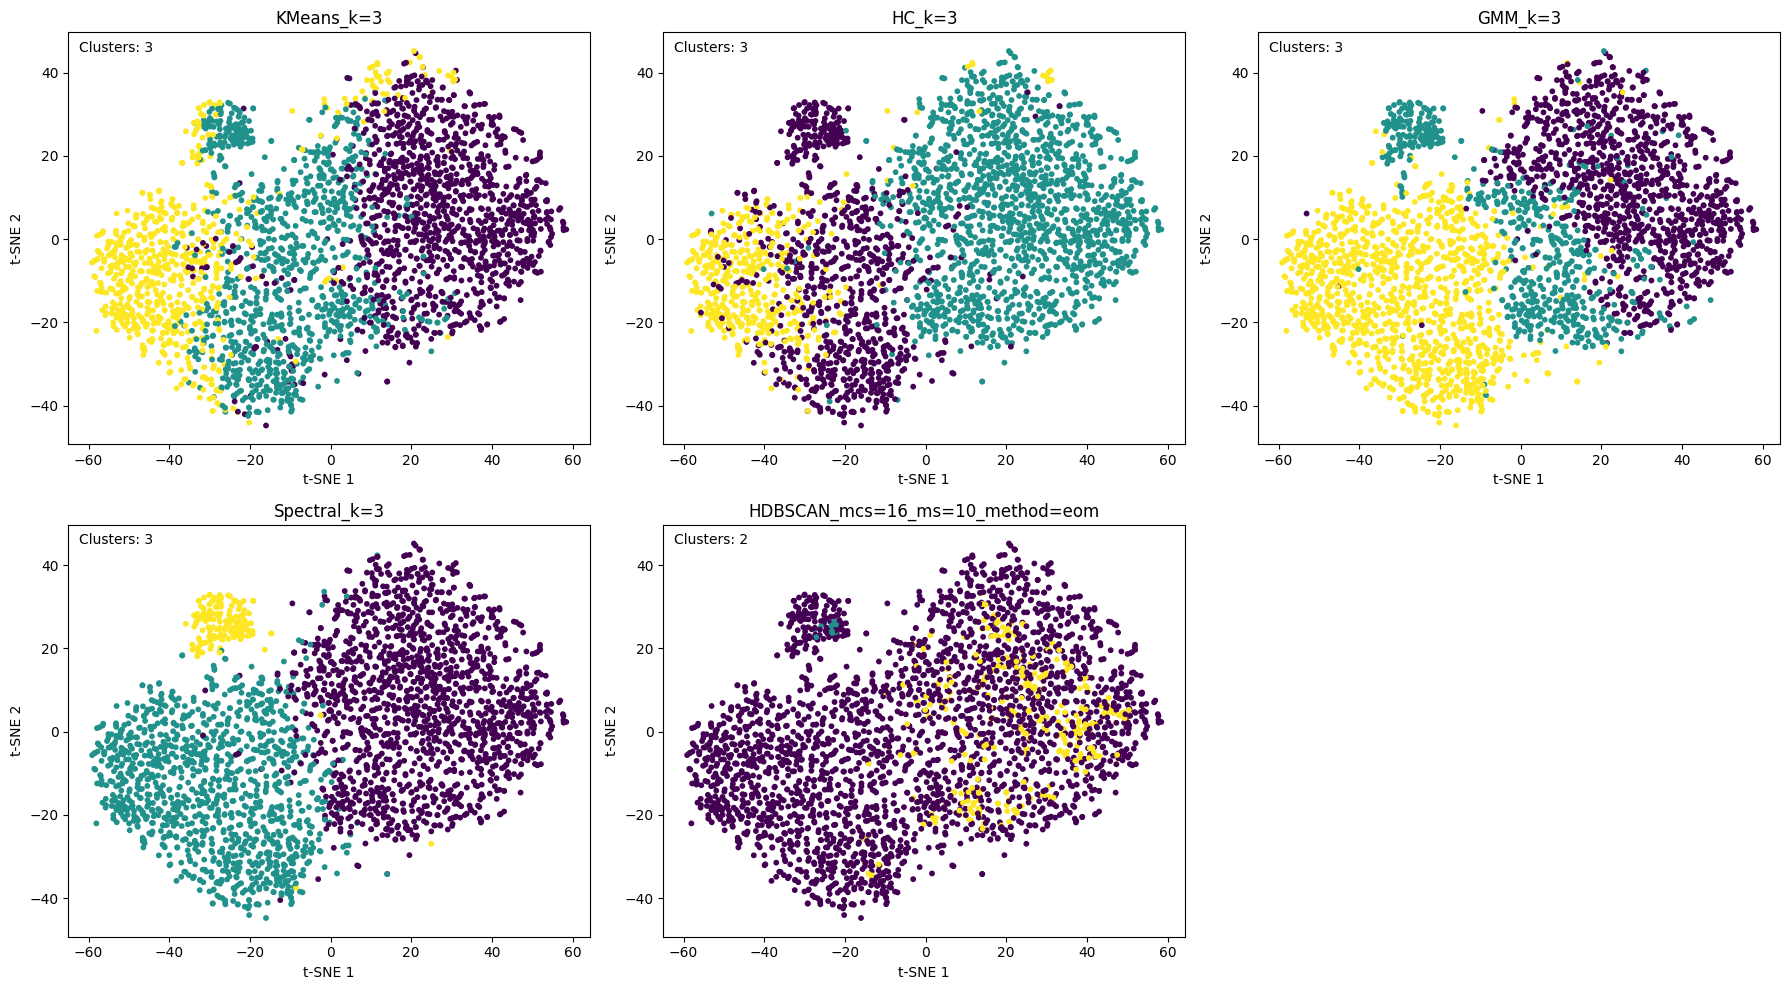

In [16]:
labels_dict = {name: df["cluster"].to_numpy() for name, df in clustered_outputs.items()}

def compute_tsne_embedding(X, max_samples=3000, pre_pca_components=30, random_state=42):
    X = np.asarray(X, dtype=np.float32)
    n_samples = X.shape[0]

    if n_samples > max_samples:
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(n_samples, size=max_samples, replace=False)
    else:
        sample_idx = np.arange(n_samples)

    X_sample = X[sample_idx]
    if X_sample.shape[1] > pre_pca_components:
        reducer = PCA(n_components=pre_pca_components, random_state=random_state)
        X_sample = reducer.fit_transform(X_sample)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    X_tsne = tsne.fit_transform(X_sample)
    return sample_idx, X_tsne

def plot_tsne_clusterings(X_tsne, labels_dict, sample_idx):
    n_plots = len(labels_dict)
    n_cols = 3
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (name, labels) in zip(axes, labels_dict.items()):
        sampled_labels = np.asarray(labels)[sample_idx]
        ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sampled_labels, s=10)
        ax.set_title(name)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

        unique_labels = set(sampled_labels)
        n_clusters = len(unique_labels - {-1}) if -1 in unique_labels else len(unique_labels)
        ax.text(0.02, 0.98, f"Clusters: {n_clusters}", transform=ax.transAxes, va="top")

    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

sample_idx, X_tsne = compute_tsne_embedding(X_train, max_samples=3000, pre_pca_components=30)
plot_tsne_clusterings(X_tsne, labels_dict, sample_idx)
